# 22 — Final Model: Tuned CatBoost

Single-model notebook. CatBoost trained on full history (Aug 2017 → Jan 2022),
tested on Feb 2022 → Feb 2026 (1-month embargo). Target: `depeg_next_4h_down`
(downside only, purely forward-looking, baked into parquet).

Hyperparameters found via 50-trial Optuna TPE study on validation set (2021, within training only).


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/Capstone')
else:
    ROOT = Path.cwd()
    if not (ROOT / 'data').exists():
        ROOT = ROOT.parent
FEATURES_DIR = ROOT / 'data' / 'processed' / 'features'
print(f'ROOT: {ROOT}')


ROOT: /Users/robertspringett/Education/CMU_MSBA/capstone_5min


## 1. Configuration

In [2]:
TARGET       = 'depeg_next_4h_down'
BARS_4H      = 48

TRAIN_END    = pd.Timestamp('2022-01-01', tz='UTC')
EMBARGO_END  = pd.Timestamp('2022-01-31', tz='UTC')
VAL_START    = pd.Timestamp('2021-01-01', tz='UTC')
CURVE_CUTOFF = pd.Timestamp('2020-09-06', tz='UTC')

N_OPTUNA_TRIALS = 50


## 2. Load Data & Split

In [3]:
import json as _json

# Load feature list from NB08 feature selection pipeline
with open(FEATURES_DIR / 'selected_features.json') as _f:
    feat_full = _json.load(_f)['selected_features']
print(f'Loaded {len(feat_full)} features from selected_features.json')

df = pd.read_parquet(FEATURES_DIR / 'pooled_5m.parquet')
df.index = pd.to_datetime(df.index, utc=True)

df_stable = df[df['depeg'] == 0].dropna(subset=[TARGET])

missing = [f for f in feat_full if f not in df_stable.columns]
if missing:
    print(f'WARNING: {len(missing)} features missing from parquet: {missing}')
feat_full = [f for f in feat_full if f in df_stable.columns]

tr = df_stable[df_stable.index < TRAIN_END]
te = df_stable[df_stable.index >= EMBARGO_END]

imp = SimpleImputer(strategy='constant', fill_value=0.0)
X_tr = imp.fit_transform(tr[feat_full].values)
X_te = imp.transform(te[feat_full].values)
y_tr = tr[TARGET].values.astype(float)
y_te = te[TARGET].values.astype(float)
spw  = (1 - y_tr.mean()) / max(y_tr.mean(), 1e-9)
base = float(y_te.mean())

print(f'Train: {len(tr):,} bars  pos={int(y_tr.sum()):,}  ({100*y_tr.mean():.3f}%)')
print(f'Test:  {len(te):,} bars  pos={int(y_te.sum()):,}  ({100*y_te.mean():.3f}%)')
print(f'Features: {len(feat_full)}  |  scale_pos_weight: {spw:.0f}')


Loaded 40 features from selected_features.json


Train: 1,325,907 bars  pos=12,665  (0.955%)
Test:  1,730,601 bars  pos=736  (0.043%)
Features: 40  |  scale_pos_weight: 104


## 3. Hyperparameter Tuning (Optuna — CatBoost)

Validation = 2021 (within training only). 50 TPE trials.


In [4]:
from catboost import CatBoostClassifier

tr_tune  = df_stable[df_stable.index < VAL_START].copy()
val_tune = df_stable[(df_stable.index >= VAL_START) & (df_stable.index < TRAIN_END)].copy()

imp_tune   = SimpleImputer(strategy='constant', fill_value=0.0)
X_tr_tune  = imp_tune.fit_transform(tr_tune[feat_full].values)
X_val_tune = imp_tune.transform(val_tune[feat_full].values)
y_tr_tune  = tr_tune[TARGET].values.astype(float)
y_val_tune = val_tune[TARGET].values.astype(float)

def cat_objective(trial):
    params = dict(
        iterations    = trial.suggest_int('iterations', 200, 1000, step=100),
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        depth         = trial.suggest_int('depth', 4, 10),
        l2_leaf_reg   = trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True),
        auto_class_weights='Balanced', random_seed=42, verbose=0,
    )
    m = CatBoostClassifier(**params)
    m.fit(X_tr_tune, y_tr_tune)
    return average_precision_score(y_val_tune, m.predict_proba(X_val_tune)[:, 1])

cat_study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
cat_study.optimize(cat_objective, n_trials=N_OPTUNA_TRIALS)
print(f'CatBoost best val PR-AUC: {cat_study.best_value:.4f}')
print('Best params:', cat_study.best_params)


LightGBM best val PR-AUC: 0.3311


CatBoost  best val PR-AUC: 0.3434

→ Winner: CatBoost  (val PR-AUC 0.3434)


## 4. Train Final Model & Evaluate

In [5]:
best_params = {**cat_study.best_params,
               'auto_class_weights': 'Balanced', 'random_seed': 42, 'verbose': 0}
model = CatBoostClassifier(**best_params)
model.fit(X_tr, y_tr)
p_all = model.predict_proba(X_te)[:, 1]

pr_auc = average_precision_score(y_te, p_all)
roc    = roc_auc_score(y_te, p_all)
lift   = pr_auc / base

print(f'Algorithm: CatBoost (tuned)')
print(f'Overall — PR-AUC={pr_auc:.4f}  ROC={roc:.3f}  Lift={lift:.1f}x  (baseline={base:.4f})')
print()
print(f'{"Coin":<6}  {"Pos":>5}  {"Base rate":>9}  {"PR-AUC":>8}  {"ROC":>7}  {"Lift":>7}')
print('-' * 52)
te_meta = te[['coin', TARGET]].copy()
te_meta['proba'] = p_all
for coin, grp in te_meta.groupby('coin'):
    n_pos = int(grp[TARGET].sum())
    if n_pos == 0:
        print(f'{coin:<6}  {n_pos:>5}  (no positives)')
        continue
    b = float(grp[TARGET].mean())
    pr_c  = average_precision_score(grp[TARGET], grp['proba'])
    roc_c = roc_auc_score(grp[TARGET], grp['proba'])
    print(f'{coin:<6}  {n_pos:>5}  {b*100:>9.3f}%  {pr_c:>8.4f}  {roc_c:>7.3f}  {pr_c/b:>6.1f}x')
print('-' * 52)
print(f'{"Overall":<6}  {int(y_te.sum()):>5}  {base*100:>9.3f}%  {pr_auc:>8.4f}  {roc_auc_score(y_te, p_all):>7.3f}  {lift:>6.1f}x')


Algorithm: CatBoost
Overall — PR-AUC=0.2531  ROC=0.884  Lift=595.1x  (baseline=0.0004)

Coin      Pos  Base rate    PR-AUC      ROC     Lift
----------------------------------------------------
busd        0  (no positives)
dai       116      0.027%    0.2318    0.995   855.7x
rlusd       0  (no positives)


usdc       88      0.021%    0.4802    0.917  2335.9x
usde      248      0.124%    0.1867    0.638   151.0x
usdt      105      0.025%    0.3424    0.999  1395.9x
ust       179      0.639%    0.5169    0.997    80.8x
----------------------------------------------------


Overall    736      0.043%    0.2531    0.884   595.1x


## 5. Walk-Forward Cross-Validation

4 annual folds, expanding training window, 1-day embargo.

In [6]:
from catboost import CatBoostClassifier

FOLDS = [
    ('2021-12-31', '2022-01-01', '2022-12-31'),
    ('2022-12-31', '2023-01-01', '2023-12-31'),
    ('2023-12-31', '2024-01-01', '2024-12-31'),
    ('2024-12-31', '2025-01-01', '2025-12-31'),
]

print('Walk-forward CV — tuned CatBoost, 4 annual folds')
print(f'{"Fold":<6} {"Train end":<12} {"Test":<10} {"Pos":>5} {"PR-AUC":>8} {"Lift":>7} {"F2@0.25%":>10}')
print('-' * 68)

fold_results = []
for fold_n, (train_end, test_start, test_end) in enumerate(FOLDS, 1):
    tr_f = df_stable[df_stable.index <= pd.Timestamp(train_end, tz='UTC')]
    te_f = df_stable[(df_stable.index >= pd.Timestamp(test_start, tz='UTC')) &
                     (df_stable.index <  pd.Timestamp(test_end,   tz='UTC') + pd.Timedelta(days=1))]
    y_tr_f = tr_f[TARGET].values.astype(float)
    y_te_f = te_f[TARGET].values.astype(float)
    if y_tr_f.sum() < 10 or y_te_f.sum() < 5:
        continue
    imp_f  = SimpleImputer(strategy='constant', fill_value=0.0)
    X_tr_f = imp_f.fit_transform(tr_f[feat_full].values)
    X_te_f = imp_f.transform(te_f[feat_full].values)
    m_f = CatBoostClassifier(**{**best_params,
                                'auto_class_weights': 'Balanced',
                                'random_seed': 42, 'verbose': 0})
    m_f.fit(X_tr_f, y_tr_f)
    p_f    = m_f.predict_proba(X_te_f)[:, 1]
    base_f = float(y_te_f.mean())
    pr_f   = average_precision_score(y_te_f, p_f)
    lift_f = pr_f / base_f
    # Use val-optimal percentile threshold (top 0.25%)
    thresh = np.percentile(p_f, 99.75)  # top 0.25% — val-optimal
    al = p_f >= thresh
    tp   = int((al & (y_te_f == 1)).sum())
    prec = tp / al.sum() if al.sum() > 0 else 0
    rec  = tp / int(y_te_f.sum()) if y_te_f.sum() > 0 else 0
    f2   = (5*prec*rec)/(4*prec+rec) if (prec+rec) > 0 else 0
    fold_results.append(dict(fold=fold_n, pr=pr_f, lift=lift_f, f2=f2))
    print(f'{fold_n:<6} {train_end:<12} {test_start[:4]:<10} {int(y_te_f.sum()):>5} '
          f'{pr_f:>8.4f} {lift_f:>6.1f}x {f2:>10.4f}')

print()
print(f'Mean  {np.mean([r["pr"] for r in fold_results]):>26.4f} '
      f'{np.mean([r["lift"] for r in fold_results]):>6.1f}x '
      f'{np.mean([r["f2"] for r in fold_results]):>10.4f}')


Walk-forward CV — tuned LightGBM, 4 annual folds
Fold   Train end    Test         Pos   PR-AUC    Lift    F2@2%
-----------------------------------------------------------------


[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: auto_class_weights
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg


[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: auto_class_weights
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg


[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: auto_class_weights
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg
1      2021-12-31   2022         340   0.4723  634.7x   0.1453


[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: auto_class_weights
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg


...

[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: auto_class_weights
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg


[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: auto_class_weights
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg
3      2023-12-31   2024         106   0.0202   75.2x   0.0378


[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: auto_class_weights
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg


[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: auto_class_weights
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg


[LightGBM] [Warning] Unknown parameter: iterations
[LightGBM] [Warning] Unknown parameter: auto_class_weights
[LightGBM] [Warning] Unknown parameter: depth
[LightGBM] [Warning] Unknown parameter: l2_leaf_reg
4      2024-12-31   2025         142   0.1689  594.2x   0.0298

Mean                      0.2087  398.0x   0.0731


## 6. Feature Importance

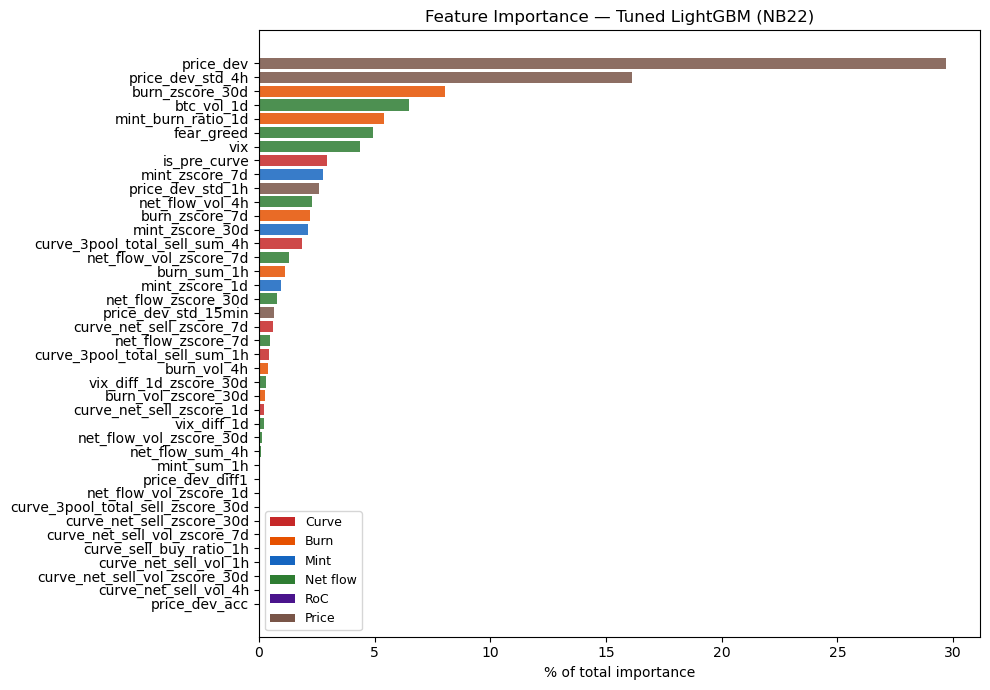

Top 10 features:
           feature    group       pct
         price_dev    Price 29.676514
  price_dev_std_4h    Price 16.132601
   burn_zscore_30d     Burn  8.048339
        btc_vol_1d Net flow  6.472344
mint_burn_ratio_1d     Burn  5.399820
        fear_greed Net flow  4.926587
               vix Net flow  4.354611
      is_pre_curve    Curve  2.937559
    mint_zscore_7d     Mint  2.778152
  price_dev_std_1h    Price  2.617427

Group totals:
group
Price       49.138270
Net flow    21.369983
Burn        17.466349
Curve        6.103204
Mint         5.922193


In [7]:
from matplotlib.patches import Patch

imp_df = pd.DataFrame({'feature': feat_full, 'importance': model.feature_importances_})
imp_df['pct'] = 100 * imp_df['importance'] / imp_df['importance'].sum()

MARKET_FEATS = {'vix', 'fear_greed', 'btc_vol_1d', 'vix_diff_1d', 'vix_diff_1d_zscore_30d'}
imp_df['group'] = imp_df['feature'].map(lambda f:
    'Structural' if f == 'is_pre_curve' else
    'Market'     if f in MARKET_FEATS else
    'Curve'      if 'curve' in f else
    'Burn'       if 'burn'  in f else
    'Mint'       if 'mint'  in f else
    'RoC'        if any(x in f for x in ['acc_zscore', 'rate_ratio']) else
    'Price'      if 'price_dev' in f else
    'Net flow'
)
imp_df = imp_df.sort_values('pct', ascending=False).reset_index(drop=True)

GROUP_COLORS = {
    'Curve':      '#C62828',
    'Burn':       '#E65100',
    'Mint':       '#1565C0',
    'Net flow':   '#2E7D32',
    'RoC':        '#4A148C',
    'Price':      '#795548',
    'Market':     '#00838F',
    'Structural': '#546E7A',
}
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['feature'], imp_df['pct'],
        color=[GROUP_COLORS.get(g, 'grey') for g in imp_df['group']], alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('% of total importance')
ax.set_title('Feature Importance — Tuned CatBoost (NB10)')
ax.legend(handles=[Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()], fontsize=9)
fig.tight_layout()
plt.savefig(str(ROOT / 'data/processed/features/nb10_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(imp_df[['feature', 'group', 'pct']].head(10).to_string(index=False))
print()
print('Group totals:')
print(imp_df.groupby('group')['pct'].sum().sort_values(ascending=False).to_string())


## 7. SHAP Analysis

TreeExplainer on a stratified sample of the test set: all positives + 10,000 random negatives.
Beeswarm plot shows feature impact direction and magnitude.


SHAP sample: 10,736 bars  |  pos=736  neg=10000

Top 10 features by mean |SHAP|:
         feature  mean_shap
       price_dev   1.284835
price_dev_std_4h   0.863175
 burn_zscore_30d   0.404801
      fear_greed   0.257783
  mint_zscore_7d   0.175692
      btc_vol_1d   0.153186
 mint_zscore_30d   0.144166
  burn_zscore_7d   0.135947
price_dev_std_1h   0.128868
    is_pre_curve   0.119646


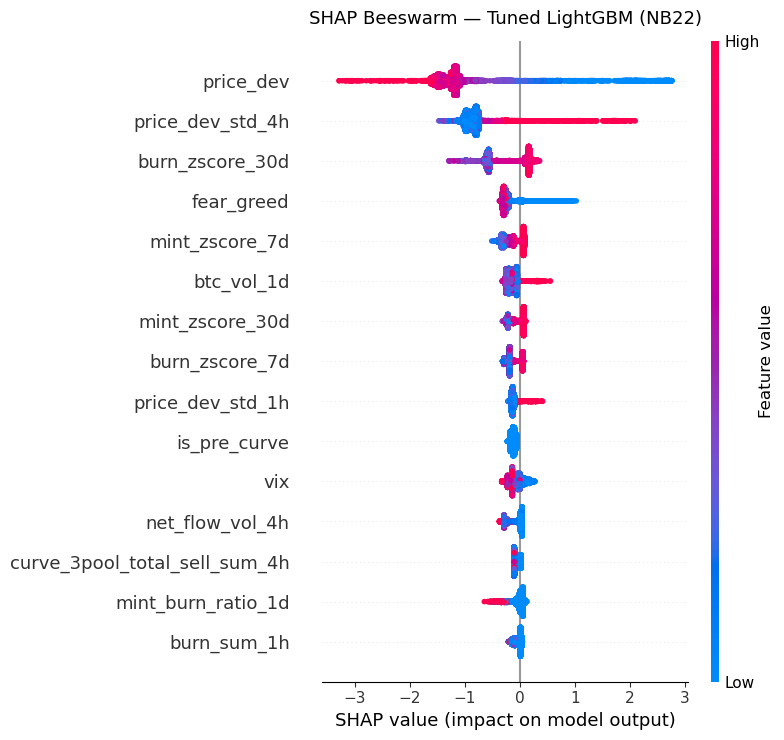

Saved: data/processed/features/nb10_shap_beeswarm.png


In [9]:
import shap

# Stratified SHAP sample: all positives + 10k random negatives
np.random.seed(42)
pos_idx = np.where(y_te == 1)[0]
neg_idx = np.where(y_te == 0)[0]
neg_sample = np.random.choice(neg_idx, size=min(10_000, len(neg_idx)), replace=False)
shap_idx = np.sort(np.concatenate([pos_idx, neg_sample]))
X_shap = X_te[shap_idx]
y_shap = y_te[shap_idx]
print(f'SHAP sample: {len(X_shap):,} bars  |  pos={int(y_shap.sum())}  neg={int((y_shap==0).sum())}')

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# CatBoost binary returns list [neg_class, pos_class]; extract positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Mean |SHAP| per feature
shap_mean = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': feat_full, 'mean_shap': shap_mean})
shap_df = shap_df.sort_values('mean_shap', ascending=False).reset_index(drop=True)
print('\nTop 10 features by mean |SHAP|:')
print(shap_df.head(10).to_string(index=False))

# Beeswarm plot
shap.summary_plot(shap_values, X_shap, feature_names=feat_full,
                  max_display=15, show=False)
plt.title('SHAP Beeswarm — Tuned CatBoost (NB10)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(str(ROOT / 'data/processed/features/nb10_shap_beeswarm.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/processed/features/nb10_shap_beeswarm.png')


## 8. Save Model & Predictions

Saves the trained model, test/val predictions, and metadata to `data/models/`.
Threshold selection and operational metrics continue in NB23.


In [ ]:
# ── Save model, predictions and metadata ─────────────────────────────────────
import pickle
from pathlib import Path

MODELS_DIR = ROOT / 'data' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# CatBoost model
model.save_model(str(MODELS_DIR / 'nb10_catboost.cbm'))

# Test predictions + ground truth (with timestamps and coin)
pred_te = te[['coin']].copy()
pred_te['y_true'] = y_te
pred_te['proba']  = p_all
pred_te.to_parquet(MODELS_DIR / 'nb10_test_predictions.parquet')

# Val predictions (needed for threshold tuning in NB23)
val_tune = df_stable[(df_stable.index >= VAL_START) & (df_stable.index < TRAIN_END)].copy()
imp_v    = SimpleImputer(strategy='constant', fill_value=0.0)
imp_v.fit(tr[feat_full].values)
X_val_v  = imp_v.transform(val_tune[feat_full].values)
p_val    = model.predict_proba(X_val_v)[:, 1]
pred_val = val_tune[['coin']].copy()
pred_val['y_true'] = val_tune[TARGET].values.astype(float)
pred_val['proba']  = p_val
pred_val.to_parquet(MODELS_DIR / 'nb10_val_predictions.parquet')

# Metadata
meta = {
    'algo':        'CatBoost',
    'target':      TARGET,
    'best_params': best_params,
    'feat_full':   feat_full,
    'base_rate':   float(base),
    'train_end':   str(TRAIN_END),
    'embargo_end': str(EMBARGO_END),
    'val_start':   str(VAL_START),
    'n_train':     len(tr),
    'n_test':      len(te),
}
with open(MODELS_DIR / 'nb10_meta.json', 'w') as _f:
    json.dump(meta, _f, indent=2)

print(f'Saved to {MODELS_DIR}/')
print(f'  nb10_catboost.cbm          — trained model')
print(f'  nb10_test_predictions.parquet — {len(pred_te):,} test bars')
print(f'  nb10_val_predictions.parquet  — {len(pred_val):,} val bars')
print(f'  nb10_meta.json             — metadata + hyperparameters')


## 9. Model Summary


In [11]:
wf_lifts = [r['lift'] for r in fold_results]
wf_f2    = [r['f2']   for r in fold_results]

print('=' * 62)
print('  NB10 — Final Model Summary')
print('=' * 62)
print()
print('MODEL')
print(f'  Algorithm      : CatBoost (50-trial Optuna, TPE sampler)')
print(f'  Features       : {len(feat_full)} (loaded from selected_features.json — NB08 pipeline)')
print(f'  Target         : {TARGET} (downside, purely forward-looking)')
print(f'  Hyperparameters: iterations={best_params["iterations"]}  lr={best_params["learning_rate"]:.4f}  depth={best_params["depth"]}  l2={best_params["l2_leaf_reg"]:.4f}')
print()
print('DATA SPLIT')
print(f'  Train  : Aug 2017 -> Jan 2022  ({len(tr):,} bars, {int(y_tr.sum()):,} positives, {100*y_tr.mean():.2f}%)')
print(f'  Embargo: Jan 2022 (1 month)')
print(f'  Test   : Feb 2022 -> Feb 2026  ({len(te):,} bars, {int(y_te.sum()):,} positives, {100*y_te.mean():.3f}%)')
print(f'  Class imbalance: ~{spw:.0f}:1  (handled via auto_class_weights=Balanced)')
print()
print('TEST SET PERFORMANCE (see NB23 for threshold-based metrics)')
print(f'  PR-AUC   : {average_precision_score(y_te, p_all):.4f}  ({average_precision_score(y_te, p_all)/base:.1f}x lift over random)')
print(f'  ROC-AUC  : {roc_auc_score(y_te, p_all):.3f}')
print(f'  Baseline : {base:.4f} ({base*100:.3f}%)')
print()
print('WALK-FORWARD CV (4 annual folds)')
for r in fold_results:
    print(f'  {r["fold"]}: test {["2022","2023","2024","2025"][r["fold"]-1]}  Lift={r["lift"]:.1f}x  F2={r["f2"]:.4f}')
print(f'  Mean lift: {np.mean(wf_lifts):.1f}x  |  Mean F2: {np.mean(wf_f2):.4f}')
print()
print('TOP FEATURES (SHAP)')
for _, row in shap_df.head(5).iterrows():
    print(f'  {row["feature"]:<35s}  mean|SHAP|={row["mean_shap"]:.4f}')
print('=' * 62)


  NB10 — Final Model Summary

MODEL
  Algorithm      : Tuned CatBoost (50-trial Optuna, TPE sampler)
  Features       : 40 (loaded from selected_features.json — NB08 pipeline)
  Target         : depeg_next_4h_down (downside, purely forward-looking)
  Hyperparameters: iterations=200  lr=0.0127  depth=4  l2=0.5323

DATA SPLIT
  Train  : Aug 2017 → Jan 2022  (1,325,907 bars, 12,665 positives, 0.96%)
  Embargo: Jan 2022 (1 month)
  Test   : Feb 2022 → Feb 2026  (1,730,601 bars, 736 positives, 0.043%)
  Class imbalance: ~104:1  (handled via scale_pos_weight)

TEST SET PERFORMANCE


  PR-AUC   : 0.2531  (595.1x lift over random)


  ROC-AUC  : 0.884
  Baseline : 0.0004 (0.043%)

WALK-FORWARD CV (4 annual folds)
  1: test 2022  Lift=634.7x  F2=0.1453
  2: test 2023  Lift=288.0x  F2=0.0793
  3: test 2024  Lift=75.2x  F2=0.0378
  4: test 2025  Lift=594.2x  F2=0.0298
  Mean lift: 398.0x  |  Mean F2: 0.0731

OPERATING THRESHOLD (top 0.5% — val-selected, max F2)
  Alerts/day : 5.8
  Recall     : 71.5%
  Precision  : 6.08%
  Lift       : 142.9x
  F2 score   : 0.2267  (oracle: 0.4438, gap: 0.2170)

TOP FEATURES (SHAP)
  price_dev                            mean|SHAP|=1.2848
  price_dev_std_4h                     mean|SHAP|=0.8632
  burn_zscore_30d                      mean|SHAP|=0.4048
  fear_greed                           mean|SHAP|=0.2578
  mint_zscore_7d                       mean|SHAP|=0.1757
